In [1]:
import pandas as pd
import numpy as np

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
import pandas as pd

df = pd.read_excel("online_retail_II.xlsx")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.shape

(525461, 8)

In [5]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

#  Observations

1. Dataset loaded successfully.
2. The dataset contains 525,461 rows and 8 columns.
3. InvoiceDate is already in datetime format.
4. Missing values are present in Description and Customer ID columns.
5. Dataset structure has been inspected and is ready for data cleaning.

In [8]:
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 6865


In [10]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [11]:
#Unique Countries
print("Total Countries:", df["Country"].nunique())
print(df["Country"].unique())

Total Countries: 40
['United Kingdom' 'France' 'USA' 'Belgium' 'Australia' 'EIRE' 'Germany'
 'Portugal' 'Japan' 'Denmark' 'Nigeria' 'Netherlands' 'Poland' 'Spain'
 'Channel Islands' 'Italy' 'Cyprus' 'Greece' 'Norway' 'Austria' 'Sweden'
 'United Arab Emirates' 'Finland' 'Switzerland' 'Unspecified' 'Malta'
 'Bahrain' 'RSA' 'Bermuda' 'Hong Kong' 'Singapore' 'Thailand' 'Israel'
 'Lithuania' 'West Indies' 'Lebanon' 'Korea' 'Brazil' 'Canada' 'Iceland']


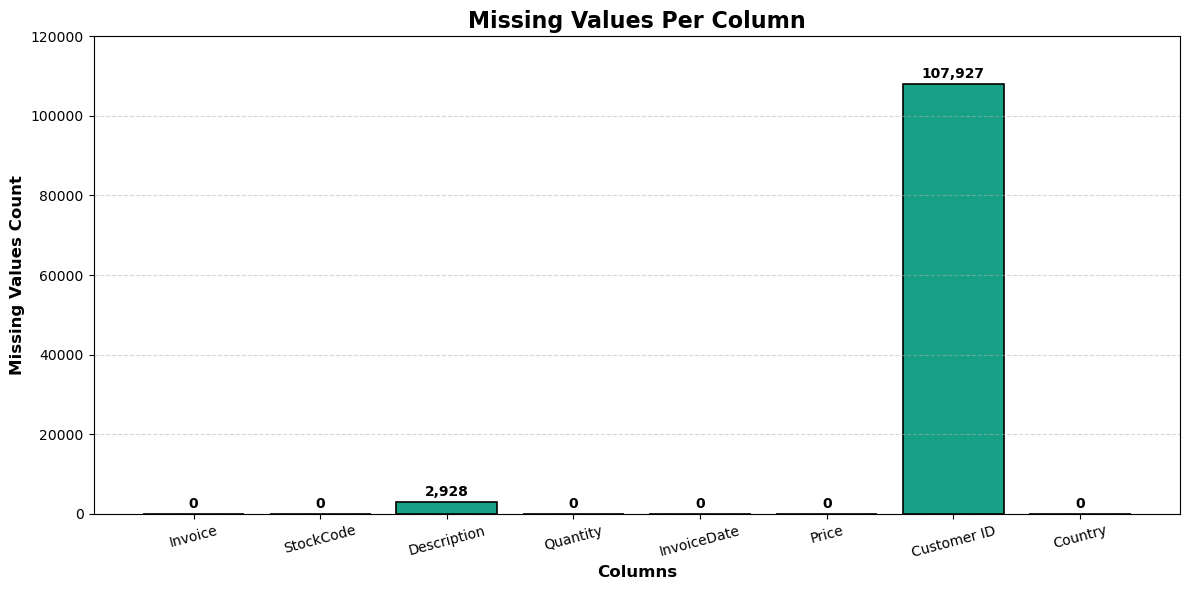

In [37]:
# Missing Values Visualization

import matplotlib.pyplot as plt

# Missing values count
missing = pd.Series({
    "Invoice": 0,
    "StockCode": 0,
    "Description": 2928,
    "Quantity": 0,
    "InvoiceDate": 0,
    "Price": 0,
    "Customer ID": 107927,
    "Country": 0
})

plt.figure(figsize=(12,6))

# Bar graph
bars = plt.bar(
    missing.index,
    missing.values,
    color="#16A085",    # Teal Green
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Missing Values Per Column",
    fontsize=16,
    fontweight="bold"
)

# Axis labels
plt.xlabel(
    "Columns",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Missing Values Count",
    fontsize=12,
    fontweight="bold"
)

# Rotate column names
plt.xticks(rotation=15)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# Better scale
plt.ylim(0, 120000)

# Value labels on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1500,
        f"{int(height):,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# Adjust layout
plt.tight_layout()

plt.show()

## Missing Values Visualization

The bar chart below shows the number of missing values present in each column of the dataset. Customer ID contains the highest number of missing values, while Description contains a small number of missing values. All other columns are complete.

In [13]:
#Negative Quantities
print("Negative Quantities:")
print((df["Quantity"] < 0).sum())

Negative Quantities:
12326


In [17]:
#Negative Prices
print("Negative Prices:")
print((df["Price"] < 0).sum())

Negative Prices:
3


In [24]:
#dataset after cleaning requirements

print("Rows before:", df.shape[0])

df = df.drop_duplicates()

print("Rows after:", df.shape[0])

Rows before: 525461
Rows after: 518596


In [25]:
df = df.dropna(subset=["Customer ID"])

print(df.isnull().sum())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


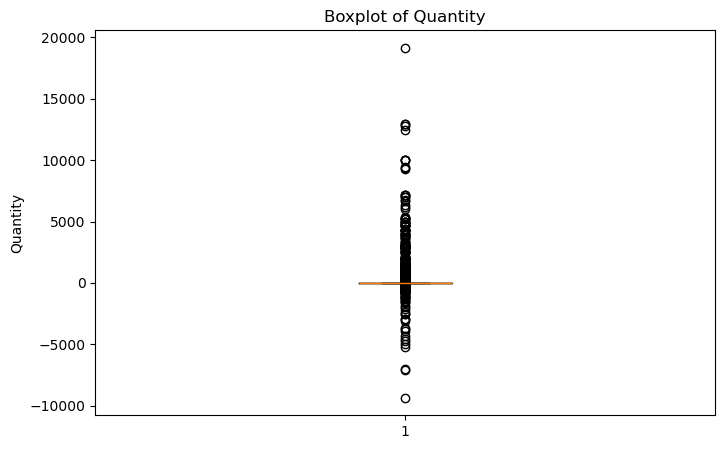

In [27]:
# Outlier Detection for Quantity

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(df["Quantity"])

plt.title("Boxplot of Quantity")

plt.ylabel("Quantity")

plt.show()

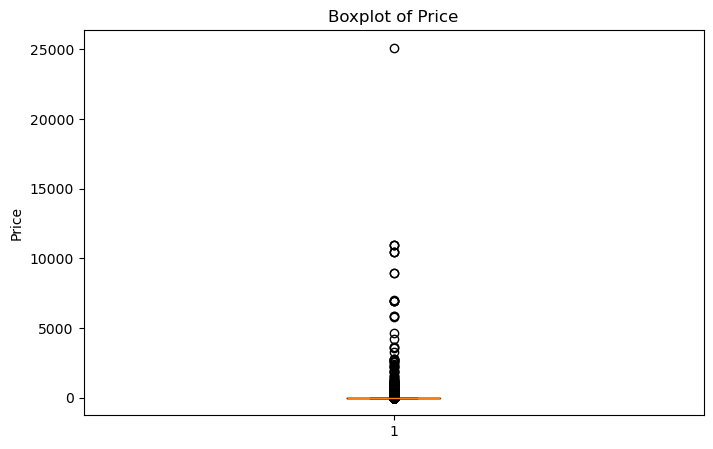

In [28]:
# Outlier Detection for Price


plt.figure(figsize=(8,5))

plt.boxplot(df["Price"])

plt.title("Boxplot of Price")

plt.ylabel("Price")

plt.show()

In [29]:
# Finding Quantity Outliers using IQR

Q1 = df["Quantity"].quantile(0.25)

Q3 = df["Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)

upper_bound = Q3 + (1.5 * IQR)

quantity_outliers = df[
    (df["Quantity"] < lower_bound) |
    (df["Quantity"] > upper_bound)
]

print("Total Quantity Outliers:", len(quantity_outliers))

Total Quantity Outliers: 27342


In [30]:
# Finding Price Outliers using IQR

Q1 = df["Price"].quantile(0.25)

Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)

upper_bound = Q3 + (1.5 * IQR)

price_outliers = df[
    (df["Price"] < lower_bound) |
    (df["Price"] > upper_bound)
]

print("Total Price Outliers:", len(price_outliers))

Total Price Outliers: 34703


In [31]:
# Checking Data Types

print(df.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [32]:
df = df.dropna(subset=["Customer ID"])

In [33]:
# Final dataset shape after cleaning

print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (410763, 8)


## Findings


1. Dataset contains missing values in Description and Customer ID columns.

2. Duplicate rows are present in the dataset.

3. Some transactions contain negative quantities (returns/cancellations).

4. A few records contain negative prices.

5. Outlier analysis was performed using Boxplot and IQR methods.



# Conclusion

The dataset was examined for missing values, duplicate records, outliers, negative values, and data type consistency.

Key data quality issues were identified and documented. The dataset is now ready for Exploratory Data Analysis (EDA), where patterns, distributions, and customer behavior trends will be explored.